# Caso Creatividad Digital 

#### Alumna: Atziry Flores Rentería
#### Docente: Pierre Antoine Delice 
#### Programación II
#### CUGDL
#### 18-03-2026

## 1- Cargar librerías y datos

In [22]:
import pandas as pd
import matplotlib.pyplot as plt 

# Cargar datos
df = pd.read_csv('campanas_creatividad_digital.csv')

# Ver primeras filas
df.head()

,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,impresiones,alcance,clicks,reproducciones_3s,reproducciones_100,conversiones,ingresos_usd,calificacion_creativa
0,CAMP-0001,2025-01-02,LumaAds,YouTube,Reel,30,Traffic,MX,2449.27,2356.84,319655,212076,4073,171648,26034,82,626.92,79
1,CAMP-0002,2025-01-03,FrameHouse,Facebook,Reel,25,Traffic,AR,1153.08,836.40,185919,103138,3718,88732,22749,93,678.65,93
2,CAMP-0003,2025-01-04,PixelForge,Facebook,Video Largo,60,Ventas,PE,398.93,291.12,50288,27514,488,22772,9557,24,1082.33,63
3,CAMP-0004,2025-01-05,FrameHouse,YouTube,Video Largo,90,Awareness,AR,1752.35,1304.59,279213,210519,2491,177098,29152,19,64.42,69
4,CAMP-0005,2025-01-06,NeoStudio,Instagram,Video Largo,45,Ventas,CL,703.80,640.98,140856,109020,1878,68165,39455,137,5787.29,73


## 2- Estructura

In [23]:
# Dimensiones
print(df.shape) 

# Tipos de datos
print(df.dtypes)

# Valores nulos
print(df.isna().sum())

# Columnas numéricas 
print(df.select_dtypes(include='number').columns)

# Columnas categóricas 
print(df.select_dtypes(include='object').columns)

# Primeras 5
print(df.head())

# Últimas 5
print(df.tail())

(180, 18)
id_campana                   str
fecha                        str
cliente                      str
plataforma                   str
formato                      str
duracion_seg               int64
objetivo                     str
pais                         str
presupuesto_usd          float64
costo_usd                float64
impresiones                int64
alcance                    int64
clicks                     int64
reproducciones_3s          int64
reproducciones_100         int64
conversiones               int64
ingresos_usd             float64
calificacion_creativa      int64
dtype: object
id_campana               0
fecha                    0
cliente                  0
plataforma               0
formato                  0
duracion_seg             0
objetivo                 0
pais                     0
presupuesto_usd          0
costo_usd                0
impresiones              0
alcance                  0
clicks                   0
reproducciones_3s        0
repr

C:\Users\atzyf\AppData\Local\Temp\ipykernel_25240\3683537443.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


### Interpretación de la estructura de datos

El dataset contiene información de campañas digitales con variables tanto numéricas como categóricas. No se observan problemas graves en los tipos de datos, y la revisión de valores nulos permite identificar si hay datos faltantes que puedan afectar el análisis.

## 3- Indicadores derivados

In [24]:
# CTR
df['ctr'] = df['clicks'] / df['impresiones']
#CVR
df['cvr'] = df['conversiones'] / df['clicks']
# CPC
df['cpc'] = df['costo_usd'] / df['clicks']
# CPM
df['cpm'] = (df['costo_usd'] / df['impresiones']) * 1000
# ROI
df['roi'] = (df['ingresos_usd'] - df['costo_usd']) / df['costo_usd']

# Verificar
df.head()


,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,...,reproducciones_3s,reproducciones_100,conversiones,ingresos_usd,calificacion_creativa,ctr,cvr,cpc,cpm,roi
0,CAMP-0001,2025-01-02,LumaAds,YouTube,Reel,30,Traffic,MX,2449.27,2356.84,...,171648,26034,82,626.92,79,0.012742,0.020133,0.578650,7.373074,-0.734000
1,CAMP-0002,2025-01-03,FrameHouse,Facebook,Reel,25,Traffic,AR,1153.08,836.40,...,88732,22749,93,678.65,93,0.019998,0.025013,0.224960,4.498733,-0.188606
2,CAMP-0003,2025-01-04,PixelForge,Facebook,Video Largo,60,Ventas,PE,398.93,291.12,...,22772,9557,24,1082.33,63,0.009704,0.049180,0.596557,5.789055,2.717814
3,CAMP-0004,2025-01-05,FrameHouse,YouTube,Video Largo,90,Awareness,AR,1752.35,1304.59,...,177098,29152,19,64.42,69,0.008922,0.007627,0.523721,4.672383,-0.950621
4,CAMP-0005,2025-01-06,NeoStudio,Instagram,Video Largo,45,Ventas,CL,703.80,640.98,...,68165,39455,137,5787.29,73,0.013333,0.072950,0.341310,4.550605,8.028815


### Interpretación de indicadores

Se calcularon métricas clave para evaluar el desempeño de las campañas. El CTR permite medir la interacción, el CVR la efectividad de conversión, y el ROI la rentabilidad. Estas métricas son fundamentales para analizar el rendimiento real de las campañas.

## 4- Preguntas de negocio

In [25]:
# q1
mediana_costo = df['costo_usd'].median()
q1 = df[(df['roi'] < 0) & (df['costo_usd'] > mediana_costo)]

print(len(q1))
print(q1['plataforma'].value_counts())

#q2
q2 = df[df['plataforma'].isin(['TikTok', 'Instagram'])]
q2 = q2.sort_values(by='roi', ascending=False).head(10)
print(q2)

#q3
q3 = df.groupby('formato')['ctr'].mean().sort_values(ascending=False)
print(q3)

#q4
q4 = df.groupby('pais')['ingresos_usd'].sum().sort_values(ascending=False)
print(q4)

36
plataforma
Instagram    11
YouTube      10
X             5
Facebook      5
TikTok        5
Name: count, dtype: int64
    id_campana       fecha     cliente plataforma      formato  duracion_seg  \
150  CAMP-0151  2025-06-01  PixelForge     TikTok        Story             5   
54   CAMP-0055  2025-02-25  PixelForge     TikTok        Story            10   
158  CAMP-0159  2025-06-09   NeoStudio     TikTok         Reel            10   
100  CAMP-0101  2025-04-12  PixelForge     TikTok     Carrusel             0   
66   CAMP-0067  2025-03-09   NeoStudio     TikTok         Reel            15   
19   CAMP-0020  2025-01-21    CromaLab     TikTok         Reel            10   
157  CAMP-0158  2025-06-08   NeoStudio     TikTok  Video Largo            90   
31   CAMP-0032  2025-02-02     LumaAds     TikTok        Story            10   
138  CAMP-0139  2025-05-20     LumaAds     TikTok         Reel            20   
22   CAMP-0023  2025-01-24  FrameHouse     TikTok       Imagen             0   


### Interpretación de preguntas de negocio

Las consultas realizadas permiten identificar campañas con bajo rendimiento, así como aquellas más exitosas. También se observa qué plataformas y formatos tienen mejor desempeño, lo cual ayuda a tomar decisiones estratégicas.

## 5- Tendencia central

In [26]:
columnas = ['costo_usd', 'ingresos_usd', 'ctr', 'cvr', 'cpc', 'cpm', 'roi']

tendencia_central = df[columnas].agg(['mean', 'median'])
print(tendencia_central)

# Por plataforma
por_plataforma = df.groupby('plataforma')[columnas].mean()
print(por_plataforma)

# Por formato
por_formato = df.groupby('formato')[columnas].mean()
print(por_formato)

# Por país
por_pais = df.groupby('pais')[columnas].mean()
print(por_pais)


          costo_usd  ingresos_usd       ctr       cvr       cpc       cpm  \
mean    1552.059222   6903.095389  0.017121  0.040058  0.341340  5.040922   
median  1411.905000   1864.945000  0.016318  0.038661  0.291472  4.835617   

             roi  
mean    3.498346  
median  0.646721  
              costo_usd  ingresos_usd       ctr       cvr       cpc       cpm  \
plataforma                                                                      
Facebook    1483.649091   4806.221515  0.016279  0.038923  0.336681  5.231254   
Instagram   1488.836809   5423.360426  0.018006  0.039541  0.305394  4.868856   
TikTok      1659.795217  13151.649130  0.021088  0.040195  0.224370  3.928090   
X           1713.446875   4772.637500  0.012764  0.044180  0.553932  6.776648   
YouTube     1491.294211   3887.259474  0.013790  0.039782  0.441927  5.704734   

                 roi  
plataforma            
Facebook    2.167606  
Instagram   3.146111  
TikTok      6.672855  
X           1.769305  
YouTu

### Hallazgos de tendencia central

El CTR promedio se encuentra dentro de los valores esperados, mientras que el ROI presenta una media positiva, lo que indica que en promedio las campañas son rentables. Sin embargo, la mediana es menor, lo que sugiere la presencia de valores altos que elevan el promedio.

## 6- Dispersión

In [27]:
dispersion = df[columnas].agg(['std', 'var', 'min', 'max'])
dispersion.loc['rango'] = dispersion.loc['max'] - dispersion.loc['min']
print(dispersion)

           costo_usd  ingresos_usd       ctr       cvr       cpc        cpm  \
std       876.228637  1.162503e+04  0.005161  0.024993  0.212825   1.330021   
var    767776.624850  1.351413e+08  0.000027  0.000625  0.045295   1.768956   
min       178.610000  2.591000e+01  0.006095  0.005562  0.097611   2.961358   
max      5992.670000  8.410028e+04  0.033894  0.090484  1.971078  12.087935   
rango    5814.060000  8.407437e+04  0.027800  0.084922  1.873467   9.126577   

             roi  
std     6.321335  
var    39.959276  
min    -0.950621  
max    33.427567  
rango  34.378188  


### Hallazgos de dispersión

El ROI presenta la mayor variabilidad entre todas las métricas, lo que indica que hay campañas con resultados muy diferentes entre sí. Esto sugiere que el desempeño no es consistente y depende de varios factores como plataforma o formato.

## 7- Outliers (CTR)

In [28]:
Q1 = df['ctr'].quantile(0.25)
Q3 = df['ctr'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_ctr = df[(df['ctr'] < lim_inf) | (df['ctr'] > lim_sup)]
print(outliers_ctr['plataforma'].value_counts())

plataforma
TikTok    3
Name: count, dtype: int64


### Análisis de outliers en CTR

Se identificaron valores atípicos en el CTR utilizando el método IQR. Estos valores corresponden principalmente a campañas con CTR muy alto, lo que indica un rendimiento fuera de lo normal en términos de interacción.

## 8- Outliers (ROI)

In [29]:
Q1 = df['roi'].quantile(0.25)
Q3 = df['roi'].quantile(0.75)

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_roi = df[(df['roi'] < lim_inf) | (df['roi'] > lim_sup)]
print(len(outliers_roi))

90


### Análisis de outliers en ROI

En el ROI se detectaron valores atípicos tanto positivos como negativos. Esto indica la presencia de campañas extremadamente rentables y otras con pérdidas significativas.

## 9- Gráficas

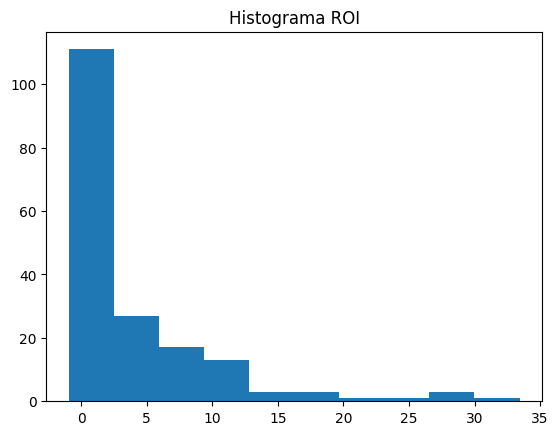

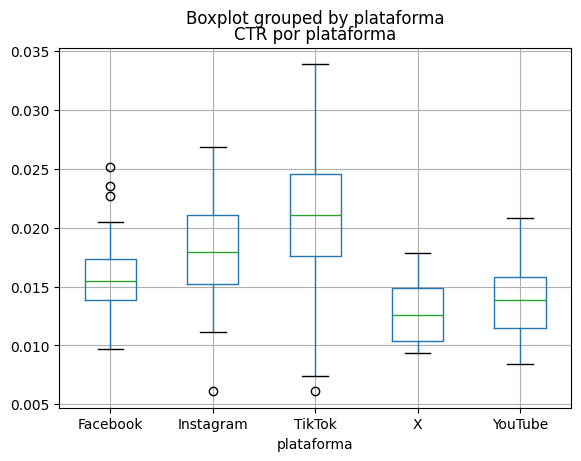

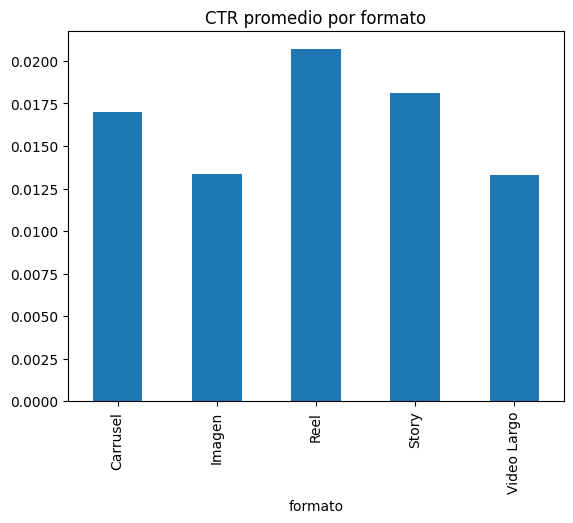

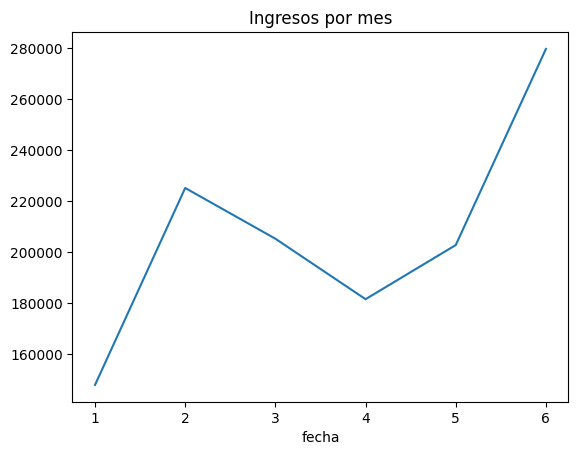

In [30]:
# histograma ROI
plt.hist(df['roi'])
plt.title('Histograma ROI')
plt.show()


# boxplot CTR por plataforma
df.boxplot(column='ctr', by='plataforma')
plt.title('CTR por plataforma')
plt.show()


# barras CTR por formato
df.groupby('formato')['ctr'].mean().plot(kind='bar')
plt.title('CTR promedio por formato')
plt.show()


# ingresos por fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df.groupby(df['fecha'].dt.month)['ingresos_usd'].sum().plot()
plt.title('Ingresos por mes')
plt.show()

### Análisis gráficas
Se observa que la mayoría de los valores de ROI se concentran en un rango específico, pero existen algunos valores extremos que representan campañas con resultados muy altos o muy bajos.

## 10- Merge con clientes

In [31]:
clientes = pd.read_csv('clientes.csv')

# left
m1 = pd.merge(df, clientes, on='cliente', how='left')

# inner
m2 = pd.merge(df, clientes, on='cliente', how='inner')

# outer
m3 = pd.merge(df, clientes, on='cliente', how='outer')

# Ver clientes sin campañas
m3[m3['id_campana'].isna()]

,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,...,cvr,cpc,cpm,roi,industria,tamano,pais_origen,nivel_contrato,descuento_pct,anios_cliente
0,NaN,NaT,BrandWave,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Automotriz,Grande,MX,Enterprise,20,9
181,NaN,NaT,ViralCo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Salud y Bienestar,Pequena,AR,Basico,3,1


### Análisis clientes
Se identificaron clientes que están en la tabla de clientes pero no tienen campañas registradas en el dataset principal.

## 11- Análisis 

In [32]:
# pm1
pm1 = m1.groupby('industria')['roi'].mean()
print(pm1)

# pm2
pm2 = m1.groupby('nivel_contrato')['ctr'].mean()
print(pm2)

# pm3
grandes = m1[m1['tamano'] == 'Grande']
positivos = grandes[grandes['roi'] > 0]

print(len(positivos))
print(len(grandes))

industria
Alimentos y Bebidas    3.489999
Entretenimiento        4.343735
Moda y Belleza         2.299934
Retail                 5.081178
Tecnologia             3.115912
Name: roi, dtype: float64
nivel_contrato
Basico        0.015769
Enterprise    0.017570
Premium       0.017384
Name: ctr, dtype: float64
37
58


### Interpretación del análisis con clientes

El análisis muestra cómo variables como industria, nivel de contrato y tamaño del cliente influyen en el desempeño de las campañas. Esto permite entender mejor qué tipo de clientes generan mejores resultados.